In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("customer_segmentation.csv")

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [5]:
df.shape

(2240, 29)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [7]:
df.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [8]:
# Check missing values first
print("Missing values before handling:\n", df.isnull().sum())

# Handle missing values more carefully
if "Income" in df.columns:
    df["Income"].fillna(df["Income"].median(), inplace=True)

# Drop rows only if critical columns are missing
df.dropna(subset=["Dt_Customer"], inplace=True)

print("\nMissing values after handling:\n", df.isnull().sum())

Missing values before handling:
 ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

Missing values after handling:
 ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome         

C:\Users\amanb\AppData\Local\Temp\ipykernel_22644\3353400472.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Income"].fillna(df["Income"].median(), inplace=True)


In [9]:
df.isna().sum().sum()

np.int64(0)

In [10]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52237.975446,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25037.955891,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35538.750000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68289.750000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [11]:
df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [12]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [13]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst = True)

In [14]:
current_year = pd.Timestamp.today().year
df["Age"] = current_year - df["Year_Birth"]

print(df["Age"].describe())

count    2240.000000
mean       57.194196
std        11.984069
min        30.000000
25%        49.000000
50%        56.000000
75%        67.000000
max       133.000000
Name: Age, dtype: float64


In [15]:
# Remove unrealistic ages
print("Before filtering:", df["Age"].describe())

df = df[(df["Age"] >= 18) & (df["Age"] <= 90)]

print("\nAfter filtering:", df["Age"].describe())
print("\nNew dataset shape:", df.shape)

Before filtering: count    2240.000000
mean       57.194196
std        11.984069
min        30.000000
25%        49.000000
50%        56.000000
75%        67.000000
max       133.000000
Name: Age, dtype: float64

After filtering: count    2237.000000
mean       57.098346
std        11.701917
min        30.000000
25%        49.000000
50%        56.000000
75%        67.000000
max        86.000000
Name: Age, dtype: float64

New dataset shape: (2237, 30)


In [16]:
df["Age"]

0       69
1       72
2       61
3       42
4       45
        ..
2235    59
2236    80
2237    45
2238    70
2239    72
Name: Age, Length: 2237, dtype: int64

In [17]:
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [18]:
df["Total_Children"]

0       0
1       2
2       0
3       1
4       1
       ..
2235    1
2236    3
2237    0
2238    1
2239    2
Name: Total_Children, Length: 2237, dtype: int64

In [19]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_Children'],
      dtype='object')

In [20]:
spend_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
df["Total_Spending"] = df[spend_cols].sum(axis = 1)

In [21]:
df[["Total_Spending"]]

,Total_Spending
0,1617
1,27
2,776
3,53
4,422
...,...
2235,1341
2236,444
2237,1241
2238,843


In [21]:
# Total purchases across all channels
df["Total_Purchases"] = (
    df["NumWebPurchases"] +
    df["NumCatalogPurchases"] +
    df["NumStorePurchases"]
)

# Avoid division by zero
df["Total_Purchases"] = df["Total_Purchases"].replace(0, 1)

# Spending per purchase (customer value)
df["Spending_per_Purchase"] = df["Total_Spending"] / df["Total_Purchases"]

# Children at home
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

print(df[["Total_Spending", "Total_Purchases", "Spending_per_Purchase", "Total_Children"]].head())

   Total_Spending  Total_Purchases  Spending_per_Purchase  Total_Children
0            1617               22              73.500000               0
1              27                4               6.750000               2
2             776               20              38.800000               0
3              53                6               8.833333               1
4             422               14              30.142857               1


In [22]:
df["Customer_Since"] = (pd.Timestamp("today") - df["Dt_Customer"]).dt.days
df["Customer_Since"]

0       4988
1       4438
2       4637
3       4464
4       4486
        ... 
2235    4706
2236    4344
2237    4480
2238    4481
2239    4947
Name: Customer_Since, Length: 2237, dtype: int64

In [23]:
# Convert to datetime if not already
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"])

# Calculate customer tenure in days
df["Customer_Tenure_Days"] = (pd.Timestamp.today() - df["Dt_Customer"]).dt.days

# Convert to years (more interpretable)
df["Customer_Tenure_Years"] = df["Customer_Tenure_Days"] / 365

print(df[["Dt_Customer", "Customer_Tenure_Years"]].head())

  Dt_Customer  Customer_Tenure_Years
0  2012-09-04              13.665753
1  2014-03-08              12.158904
2  2013-08-21              12.704110
3  2014-02-10              12.230137
4  2014-01-19              12.290411


In [24]:
df.info

<bound method DataFrame.info of          ID  Year_Birth   Education Marital_Status   Income  Kidhome  \
0      5524        1957  Graduation         Single  58138.0        0   
1      2174        1954  Graduation         Single  46344.0        1   
2      4141        1965  Graduation       Together  71613.0        0   
3      6182        1984  Graduation       Together  26646.0        1   
4      5324        1981         PhD        Married  58293.0        1   
...     ...         ...         ...            ...      ...      ...   
2235  10870        1967  Graduation        Married  61223.0        0   
2236   4001        1946         PhD       Together  64014.0        2   
2237   7270        1981  Graduation       Divorced  56981.0        0   
2238   8235        1956      Master       Together  69245.0        0   
2239   9405        1954         PhD        Married  52869.0        1   

      Teenhome Dt_Customer  Recency  MntWines  ...  Z_Revenue  Response  Age  \
0            0  2012-09

In [25]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,Z_Revenue,Response,Age,Total_Children,Total_Spending,Total_Purchases,Spending_per_Purchase,Customer_Since,Customer_Tenure_Days,Customer_Tenure_Years
count,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237,2237.000000,2237.000000,2237.000000,2237.000000,...,2237.0,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000
mean,5590.726419,1968.901654,52227.407689,0.444345,0.506482,2013-07-10 05:01:54.260169728,49.104604,303.995530,26.270451,166.916853,...,11.0,0.149307,57.098346,0.950827,605.743406,12.546714,38.105104,4678.790344,4678.790344,12.818604
min,0.000000,1940.000000,1730.000000,0.000000,0.000000,2012-07-30 00:00:00,0.000000,0.000000,0.000000,0.000000,...,11.0,0.000000,30.000000,0.000000,5.000000,1.000000,2.666667,4325.000000,4325.000000,11.849315
25%,2829.000000,1959.000000,35523.000000,0.000000,0.000000,2013-01-16 00:00:00,24.000000,24.000000,1.000000,16.000000,...,11.0,0.000000,49.000000,0.000000,69.000000,6.000000,13.000000,4506.000000,4506.000000,12.345205
50%,5455.000000,1970.000000,51381.500000,0.000000,0.000000,2013-07-08 00:00:00,49.000000,174.000000,8.000000,67.000000,...,11.0,0.000000,56.000000,1.000000,396.000000,12.000000,29.642857,4681.000000,4681.000000,12.824658
75%,8427.000000,1977.000000,68281.000000,1.000000,1.000000,2013-12-30 00:00:00,74.000000,504.000000,33.000000,232.000000,...,11.0,0.000000,67.000000,1.000000,1045.000000,18.000000,49.125000,4854.000000,4854.000000,13.298630
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,2014-06-29 00:00:00,99.000000,1493.000000,199.000000,1725.000000,...,11.0,1.000000,86.000000,3.000000,2525.000000,32.000000,1679.000000,5024.000000,5024.000000,13.764384
std,3245.118591,11.701917,25043.266830,0.538467,0.544593,NaN,28.956073,336.574382,39.715972,225.661158,...,0.0,0.356471,11.701917,0.752037,601.840466,7.201432,45.876289,202.137961,202.137961,0.553803


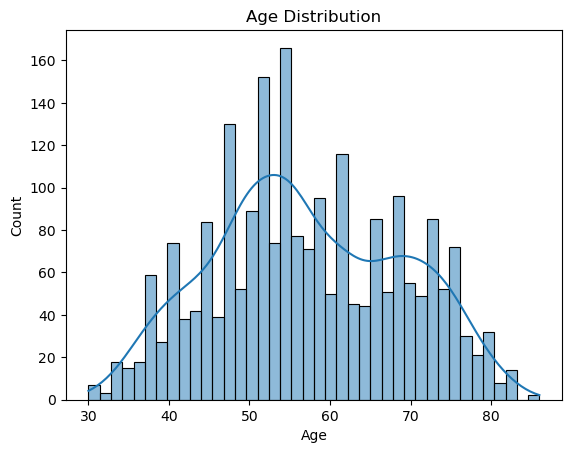

In [26]:
sns.histplot(df["Age"], bins = 40, kde= True)
plt.title("Age Distribution")
plt.show()

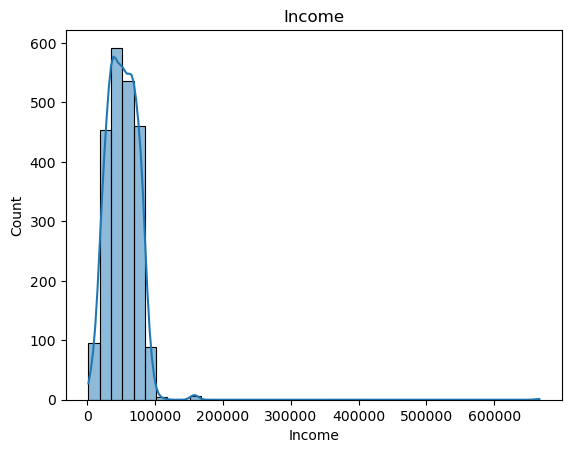

In [27]:
sns.histplot(df["Income"], bins = 40, kde = True)
plt.title("Income")
plt.show()

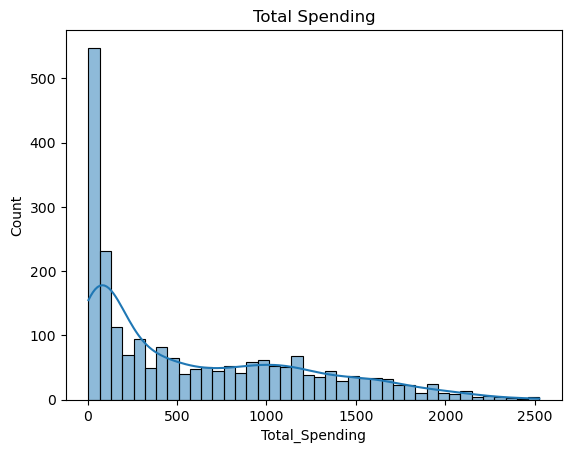

In [28]:
sns.histplot(df["Total_Spending"], bins = 40, kde = True)
plt.title("Total Spending")
plt.show()

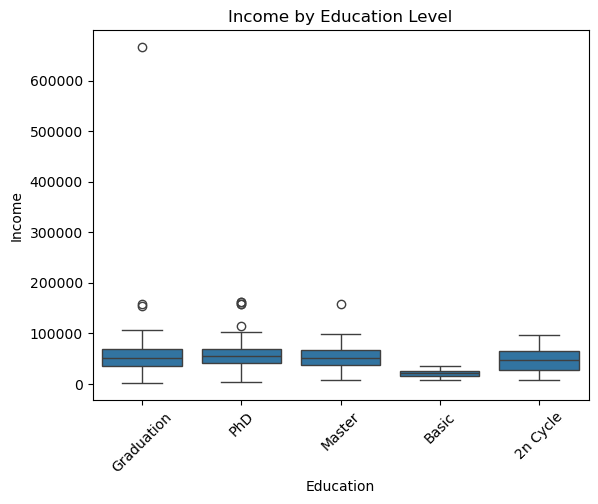

In [29]:
sns.boxplot(x= "Education", y = "Income", data = df)
plt.xticks(rotation = 45)
plt.title("Income by Education Level")
plt.show()

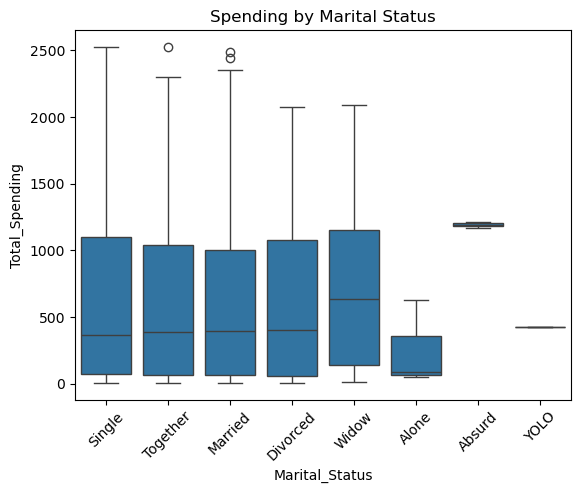

In [30]:
sns.boxplot(x= "Marital_Status", y = "Total_Spending", data = df)
plt.xticks(rotation = 45)
plt.title("Spending by Marital Status")
plt.show()

In [31]:
corr = df[["Income", "Age", "Recency", "Total_Spending", "NumWebPurchases", "NumStorePurchases"]].corr()

In [32]:
corr

,Income,Age,Recency,Total_Spending,NumWebPurchases,NumStorePurchases
Income,1.000000,0.162346,-0.003205,0.664707,0.380847,0.527346
Age,0.162346,1.000000,0.019670,0.113865,0.153973,0.139465
Recency,-0.003205,0.019670,1.000000,0.021199,-0.010616,0.001117
Total_Spending,0.664707,0.113865,0.021199,1.000000,0.519993,0.675573
NumWebPurchases,0.380847,0.153973,-0.010616,0.519993,1.000000,0.502277
NumStorePurchases,0.527346,0.139465,0.001117,0.675573,0.502277,1.000000


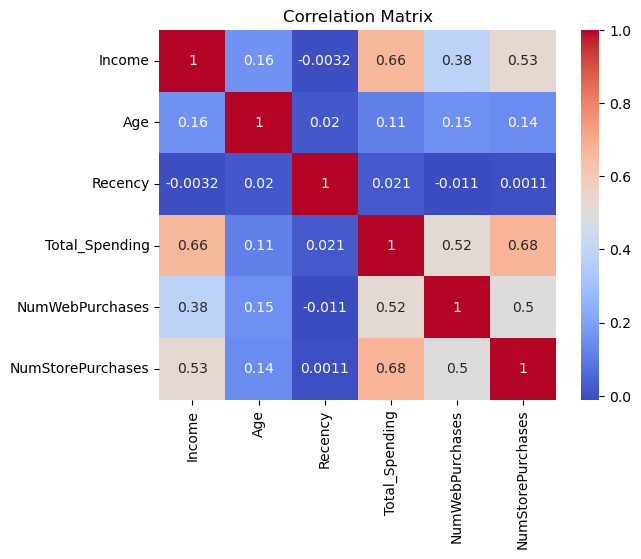

In [33]:
sns.heatmap(corr, annot = True, cmap = "coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [34]:
pivot_income = df.pivot_table(values = "Income", index = "Education", columns = "Marital_Status", aggfunc = "mean")

In [35]:
pivot_income

Marital_Status,Absurd,Alone,Divorced,Married,Single,Together,Widow,YOLO
Education,,,,,,,,
2n Cycle,NaN,NaN,49974.909091,46265.055556,53429.486111,44852.991228,51392.200000,NaN
Basic,NaN,NaN,9548.000000,21960.500000,18238.666667,21240.071429,22123.000000,NaN
Graduation,79244.0,34176.0,54526.042017,50805.628176,51323.595238,55743.176573,54976.657143,NaN
Master,65487.0,61331.0,50331.945946,53286.028986,53530.560000,52081.556604,57816.541667,NaN
PhD,NaN,35860.0,53096.615385,58067.651042,53275.163265,55764.262931,60288.083333,48432.0


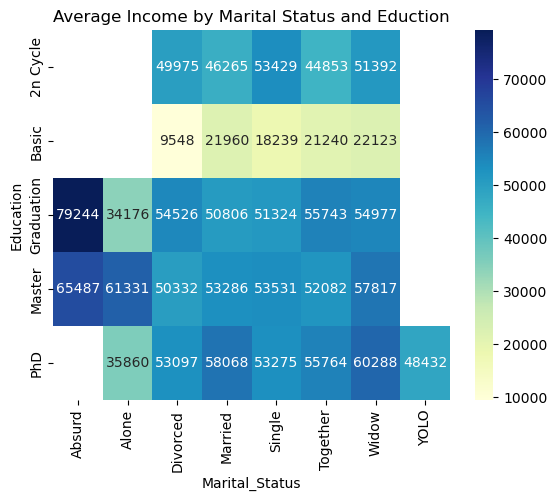

In [36]:
sns.heatmap(pivot_income, annot = True, fmt = "0.0f", cmap = "YlGnBu")
plt.title("Average Income by Marital Status and Eduction")
plt.show()


In [37]:
group1 = df.groupby("Education")["Total_Spending"].mean().sort_values(ascending = False)
group1

Education
PhD           669.975258
Graduation    619.898846
Master        611.781081
2n Cycle      501.034826
Basic          81.796296
Name: Total_Spending, dtype: float64

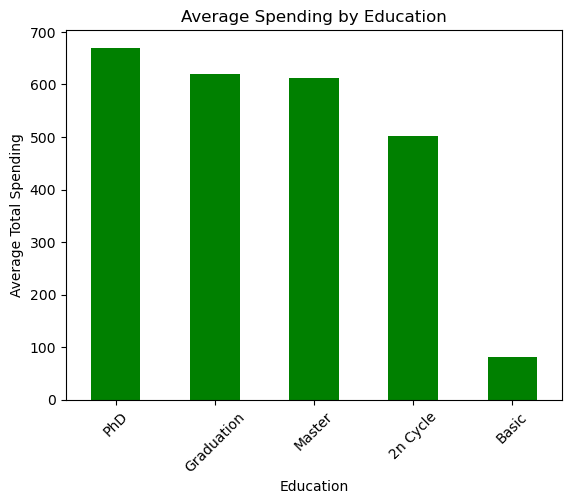

In [38]:
group1.plot(kind = "bar", color = "green")
plt.title("Average Spending by Education")
plt.ylabel("Average Total Spending")
plt.xticks(rotation = 45)
plt.show()

In [39]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_Children', 'Total_Spending', 'Total_Purchases',
       'Spending_per_Purchase', 'Customer_Since', 'Customer_Tenure_Days',
       'Customer_Tenure_Years'],
      dtype='object')

In [40]:
df["AcceptedAny"] = df[["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5", "Response"]].sum(axis= 1)
df["AcceptedAny"].unique()

array([1, 0, 3, 2, 4, 5])

In [41]:
df["AcceptedAny"] = df["AcceptedAny"].apply(lambda x : 1 if x >0 else 0)
df["AcceptedAny"].unique()

array([1, 0])

In [42]:
group2 = df.groupby("Marital_Status")["AcceptedAny"].mean().sort_values(ascending = False)
group2

Marital_Status
Absurd      0.500000
YOLO        0.500000
Widow       0.350649
Alone       0.333333
Single      0.308977
Divorced    0.298701
Married     0.251157
Together    0.248705
Name: AcceptedAny, dtype: float64

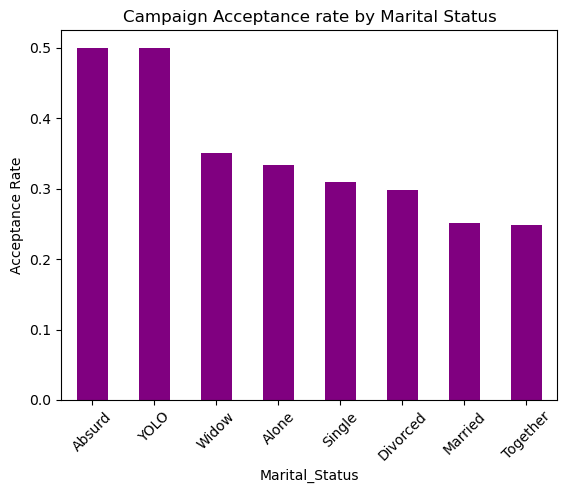

In [43]:
group2.plot(kind = "bar", color = "purple")
plt.title("Campaign Acceptance rate by Marital Status")
plt.ylabel("Acceptance Rate")
plt.xticks(rotation = 45)
plt.show()

In [44]:
bins = [18, 30, 40, 50, 60, 70, 90]
labels = ["18-29", "30-39", "40-49", "50-59", "60-69", "70+"]

In [45]:
df["AgeGroup"] = pd.cut(df["Age"], bins = bins, labels = labels)

In [46]:
df["AgeGroup"]

0       60-69
1         70+
2       60-69
3       40-49
4       40-49
        ...  
2235    50-59
2236      70+
2237    40-49
2238    60-69
2239      70+
Name: AgeGroup, Length: 2237, dtype: category
Categories (6, object): ['18-29' < '30-39' < '40-49' < '50-59' < '60-69' < '70+']

In [47]:
group3 = df.groupby("AgeGroup")["Income"].mean()
group3

C:\Users\amanb\AppData\Local\Temp\ipykernel_22644\197233607.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group3 = df.groupby("AgeGroup")["Income"].mean()


AgeGroup
18-29    10960.500000
30-39    47942.652406
40-49    48083.863636
50-59    50488.540876
60-69    55914.604675
70+      58686.145205
Name: Income, dtype: float64

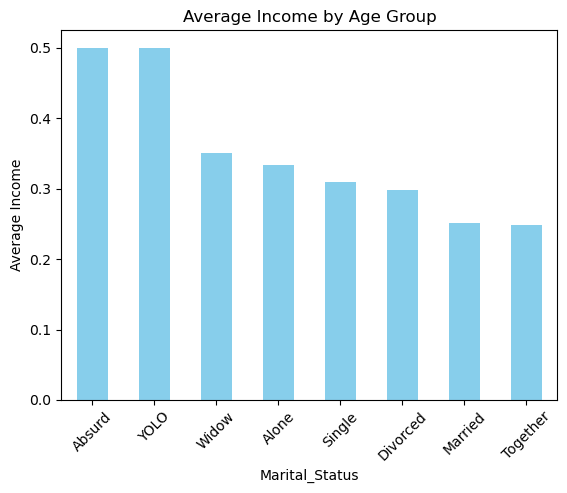

In [48]:
group2.plot(kind = "bar", color = "skyblue")
plt.title("Average Income by Age Group")
plt.ylabel("Average Income")
plt.xticks(rotation = 45)
plt.show()

In [49]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_Children', 'Total_Spending', 'Total_Purchases',
       'Spending_per_Purchase', 'Customer_Since', 'Customer_Tenure_Days',
       'Customer_Tenure_Years', 'AcceptedAny', 'AgeGroup'],
      dtype='object')

In [51]:
features = [
    "Age",
    "Income",
    "Recency",
    "Total_Spending",
    "Total_Purchases",
    "Spending_per_Purchase",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth",
    "Customer_Tenure_Years",
    "Total_Children"
]

X = df[features]

print("Selected features shape:", X.shape)
X.head()

Selected features shape: (2237, 12)


,Age,Income,Recency,Total_Spending,Total_Purchases,Spending_per_Purchase,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Customer_Tenure_Years,Total_Children
0,69,58138.0,58,1617,22,73.500000,8,10,4,7,13.665753,0
1,72,46344.0,38,27,4,6.750000,1,1,2,5,12.158904,2
2,61,71613.0,26,776,20,38.800000,8,2,10,4,12.704110,0
3,42,26646.0,26,53,6,8.833333,2,0,4,6,12.230137,1
4,45,58293.0,94,422,14,30.142857,5,3,6,5,12.290411,1


In [52]:
X = df[features].copy()

In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for readability
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Scaled data preview:")
X_scaled.head()


Scaled data preview:


,Age,Income,Recency,Total_Spending,Total_Purchases,Spending_per_Purchase,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Customer_Tenure_Years,Total_Children
0,1.017296,0.236068,0.307272,1.680649,1.312989,0.771702,1.408080,2.510435,-0.552077,0.692882,1.530038,-1.264618
1,1.273722,-0.234982,-0.383584,-0.961838,-1.187073,-0.683624,-1.110957,-0.568802,-1.167421,-0.131574,-1.191484,1.395420
2,0.333495,0.774257,-0.798098,0.282956,1.035204,0.015151,1.408080,-0.226664,1.293956,-0.543802,-0.206788,-1.264618
3,-1.290534,-1.021717,-0.798098,-0.918627,-0.909288,-0.638201,-0.751094,-0.910939,-0.552077,0.280654,-1.062830,0.065401
4,-1.034108,0.242259,1.550812,-0.305371,0.201850,-0.173598,0.328493,0.115473,0.063267,-0.131574,-0.953970,0.065401


In [ ]:
# Blank

In [54]:
#Blank

c:\Users\amanb\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\amanb\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\amanb\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\amanb\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

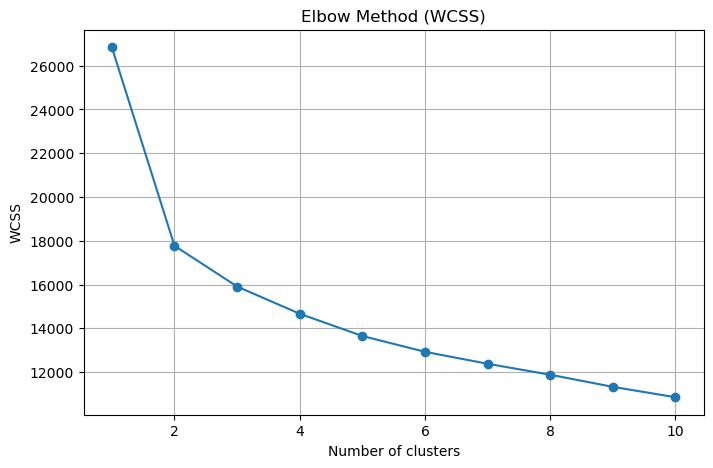

In [55]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=20)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method (WCSS)")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.grid()
plt.show()

c:\Users\amanb\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\amanb\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\amanb\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\amanb\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

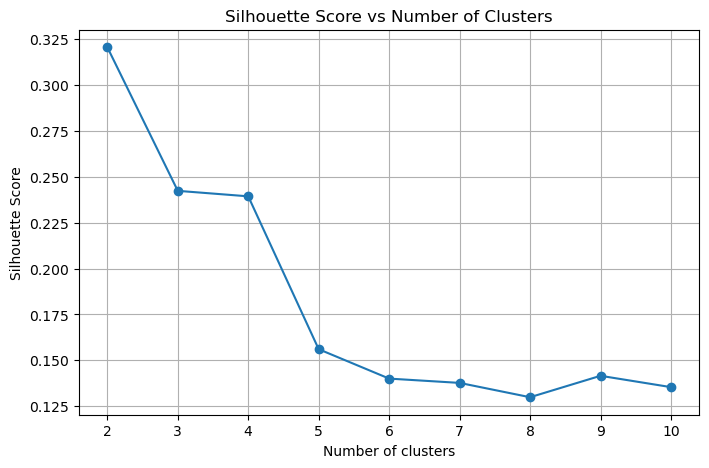

Best K based on Silhouette Score: 2


In [56]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title("Silhouette Score vs Number of Clusters")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette Score")
plt.grid()
plt.show()

# Print best K
best_k = range(2, 11)[silhouette_scores.index(max(silhouette_scores))]
print("Best K based on Silhouette Score:", best_k)

In [59]:
from sklearn.cluster import KMeans

k_values = [2, 4, 5]

cluster_results = {}

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_scaled)
    
    df[f"Cluster_K{k}"] = labels
    cluster_results[k] = labels
    
    print(f"\nK = {k}")
    print("Silhouette Score:", silhouette_score(X_scaled, labels))

c:\Users\amanb\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(



K = 2
Silhouette Score: 0.3205532831715717


c:\Users\amanb\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(



K = 4
Silhouette Score: 0.2393245295764401


c:\Users\amanb\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(



K = 5
Silhouette Score: 0.15603005515667637


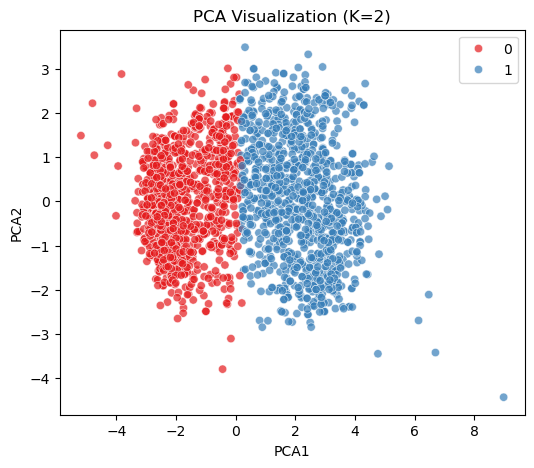

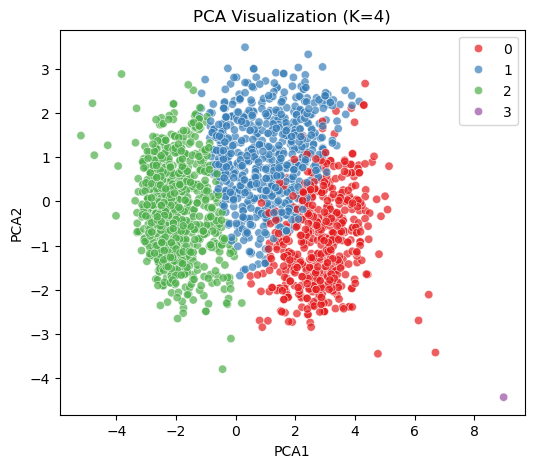

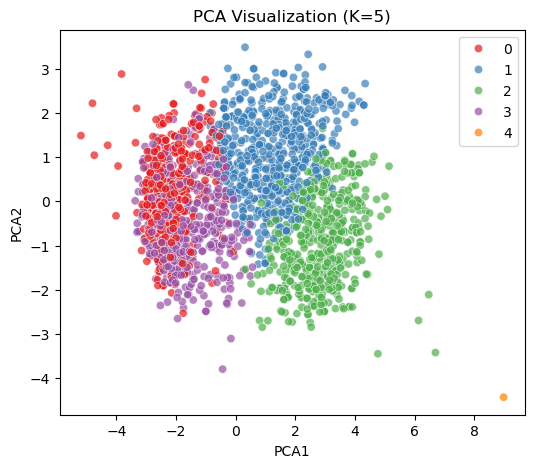

In [61]:
from sklearn.decomposition import PCA
import seaborn as sns

# Reduce to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df["PCA1"] = X_pca[:, 0]
df["PCA2"] = X_pca[:, 1]

# Plot for each K
for k in [2, 4, 5]:
    plt.figure(figsize=(6,5))
    sns.scatterplot(
        x="PCA1",
        y="PCA2",
        hue=f"Cluster_K{k}",
        data=df,
        palette="Set1",
        alpha=0.7
    )
    plt.title(f"PCA Visualization (K={k})")
    plt.legend()
    plt.show()

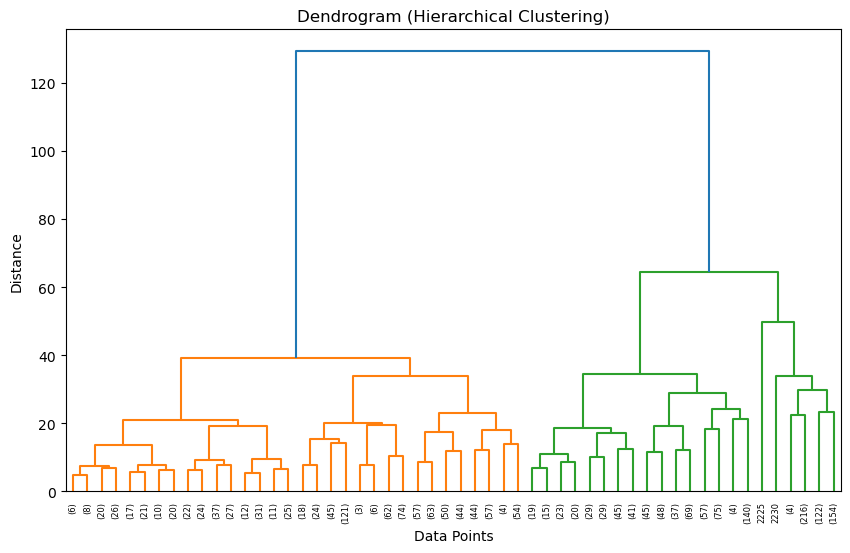

In [62]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10,6))
dendrogram(linked, truncate_mode='level', p=5)
plt.title("Dendrogram (Hierarchical Clustering)")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

In [63]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

agg = AgglomerativeClustering(n_clusters=4, linkage='ward')
df["Cluster_Agg"] = agg.fit_predict(X_scaled)

print("Agglomerative Silhouette Score:",
      silhouette_score(X_scaled, df["Cluster_Agg"]))

Agglomerative Silhouette Score: 0.21959116561560804


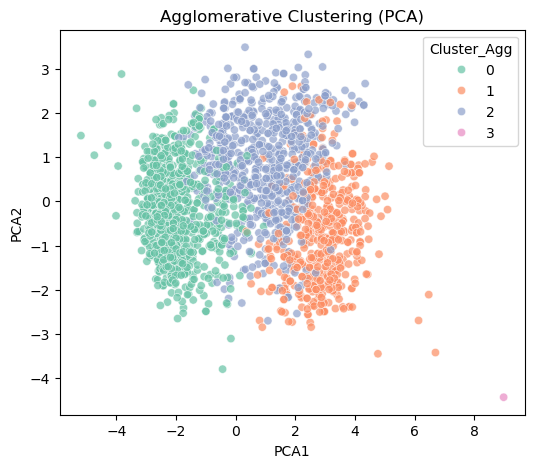

In [64]:
plt.figure(figsize=(6,5))

sns.scatterplot(
    x="PCA1",
    y="PCA2",
    hue="Cluster_Agg",
    data=df,
    palette="Set2",
    alpha=0.7
)

plt.title("Agglomerative Clustering (PCA)")
plt.show()

In [66]:
from sklearn.cluster import DBSCAN

for eps in [1.5, 1.8, 2.0, 2.5]:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_scaled)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise = list(labels).count(-1)
    
    print(f"\neps = {eps}")
    print("Clusters:", n_clusters)
    print("Noise points:", noise)


eps = 1.5
Clusters: 8
Noise points: 478

eps = 1.8
Clusters: 1
Noise points: 155

eps = 2.0
Clusters: 1
Noise points: 67

eps = 2.5
Clusters: 1
Noise points: 21


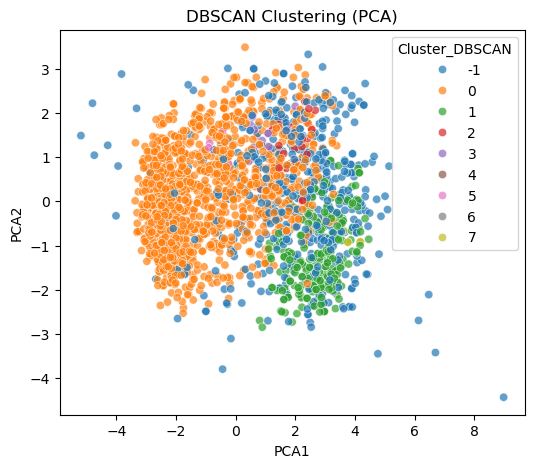

In [67]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
df["Cluster_DBSCAN"] = dbscan.fit_predict(X_scaled)

plt.figure(figsize=(6,5))
sns.scatterplot(
    x="PCA1",
    y="PCA2",
    hue="Cluster_DBSCAN",
    data=df,
    palette="tab10",
    alpha=0.7
)
plt.title("DBSCAN Clustering (PCA)")
plt.show()

Data has moderate cluster structure 

Best modeled using centroid-based methods (KMeans)

Not suitable for density-based clustering (DBSCAN)

In [68]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

gmm = GaussianMixture(n_components=4, random_state=42)
df["Cluster_GMM"] = gmm.fit_predict(X_scaled)

print("GMM Silhouette Score:",
      silhouette_score(X_scaled, df["Cluster_GMM"]))

GMM Silhouette Score: 0.2922311405572534


c:\Users\amanb\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


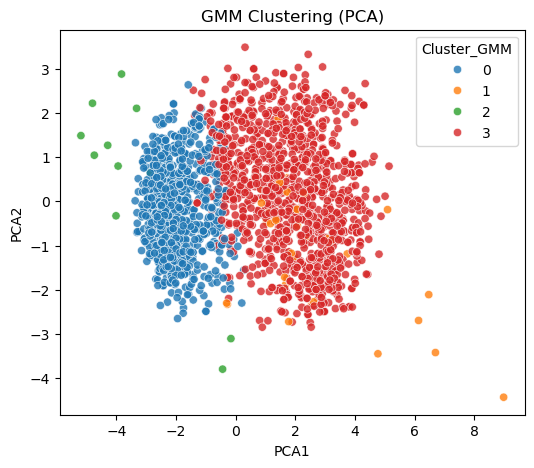

In [70]:
plt.figure(figsize=(6,5))

sns.scatterplot(
    x="PCA1",
    y="PCA2",
    hue="Cluster_GMM",
    data=df,
    palette="tab10",   # strong distinct colors
    alpha=0.8
)

plt.title("GMM Clustering (PCA)")
plt.show()

KMeans:

Forced equal partitions, 
Split center unnaturally, 
ignored probabilistic overlap, 

GMM:

Allows overlapping distributions, 
Doesn’t force hard boundaries, 
Captures true data structure, 

Multiple clustering algorithms were tested:
KMeans and Agglomerative showed moderate performance
DBSCAN was not suitable due to lack of density-based separation
Gaussian Mixture Model performed best, indicating that
the data contains overlapping and probabilistic cluster structures

In [71]:
cluster_profile = df.groupby("Cluster_GMM").mean(numeric_only=True)

cluster_profile.T

Cluster_GMM,0,1,2,3
ID,5598.798845,5775.571429,7554.000000,5559.083333
Year_Birth,1970.952839,1970.085714,1968.363636,1967.020833
Income,35330.930221,102835.985714,32485.454545,66117.426215
Kidhome,0.776708,0.314286,0.272727,0.150174
Teenhome,0.487969,0.371429,0.363636,0.528646
Recency,49.273340,47.828571,50.545455,48.977431
MntWines,43.820982,736.514286,27.272727,528.151042
MntFruits,4.841193,52.657143,3.636364,45.012153
MntMeatProducts,22.881617,585.085714,11.454545,285.603299
MntFishProducts,6.917228,61.400000,1.818182,64.742188


In [72]:
cluster_names = {
    0: "Budget Customers",
    1: "Premium Customers",
    2: "Inactive Customers",
    3: "Regular Customers"
}

df["Customer_Segment"] = df["Cluster_GMM"].map(cluster_names)

In [75]:
# Create reverse mapping (cluster number → name)
cluster_names = {
    0: "Budget Customers",
    1: "Premium Customers",
    2: "Inactive Customers",
    3: "Regular Customers"
}

# Group by original cluster number (more reliable)
summary = df.groupby("Cluster_GMM").agg({
    "Income": "mean",
    "Total_Spending": "mean",
    "Total_Purchases": "mean",
    "Spending_per_Purchase": "mean",
    "NumWebVisitsMonth": "mean"
}).round(2)

# Loop with cluster number + name
for cluster_id, row in summary.iterrows():
    segment_name = cluster_names.get(cluster_id, "Unknown")
    
    print(f"\n🔹 Cluster {cluster_id} — {segment_name}")
    
    print(f"- Average Income: {row['Income']}")
    print(f"- Total Spending: {row['Total_Spending']}")
    print(f"- Total Purchases: {row['Total_Purchases']}")
    print(f"- Spending per Purchase: {row['Spending_per_Purchase']}")
    print(f"- Web Visits per Month: {row['NumWebVisitsMonth']}")
    
    # Interpretation
    if row["Total_Spending"] > summary["Total_Spending"].mean():
        print("👉 High spending customers")
    else:
        print("👉 Low spending customers")
        
    if row["Total_Purchases"] > summary["Total_Purchases"].mean():
        print("👉 Frequent buyers")
    else:
        print("👉 Less frequent buyers")
        
    if row["NumWebVisitsMonth"] > summary["NumWebVisitsMonth"].mean():
        print("👉 High browsing activity")


🔹 Cluster 0 — Budget Customers
- Average Income: 35330.93
- Total Spending: 97.56
- Total Purchases: 5.97
- Spending per Purchase: 14.06
- Web Visits per Month: 6.38
👉 Low spending customers
👉 Less frequent buyers

🔹 Cluster 1 — Premium Customers
- Average Income: 102835.99
- Total Spending: 1541.17
- Total Purchases: 13.26
- Spending per Purchase: 162.47
- Web Visits per Month: 3.57
👉 High spending customers
👉 Frequent buyers

🔹 Cluster 2 — Inactive Customers
- Average Income: 32485.45
- Total Spending: 73.73
- Total Purchases: 1.09
- Spending per Purchase: 56.77
- Web Visits per Month: 14.18
👉 Low spending customers
👉 Less frequent buyers
👉 High browsing activity

🔹 Cluster 3 — Regular Customers
- Average Income: 66117.43
- Total Spending: 1040.74
- Total Purchases: 18.56
- Spending per Purchase: 55.83
- Web Visits per Month: 4.34
👉 High spending customers
👉 Frequent buyers


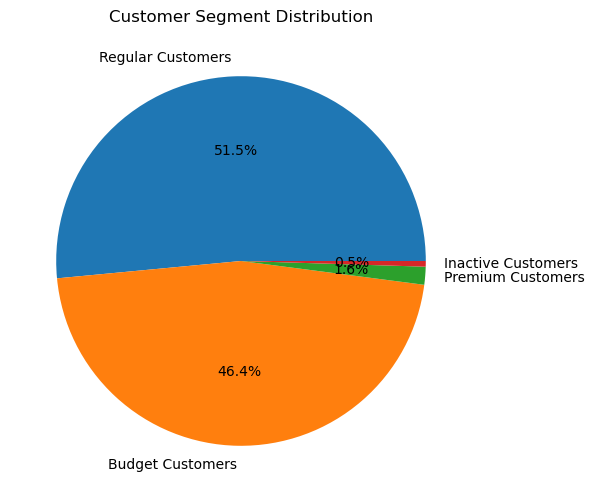

In [76]:
df["Customer_Segment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)
plt.title("Customer Segment Distribution")
plt.ylabel("")
plt.show()

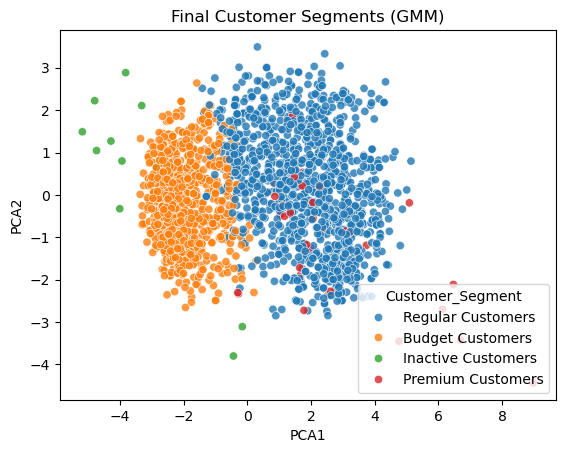

In [78]:
sns.scatterplot(
    x="PCA1",
    y="PCA2",
    hue="Customer_Segment",
    data=df,
    palette="tab10",
    alpha=0.8
)
plt.title("Final Customer Segments (GMM)")
plt.show()

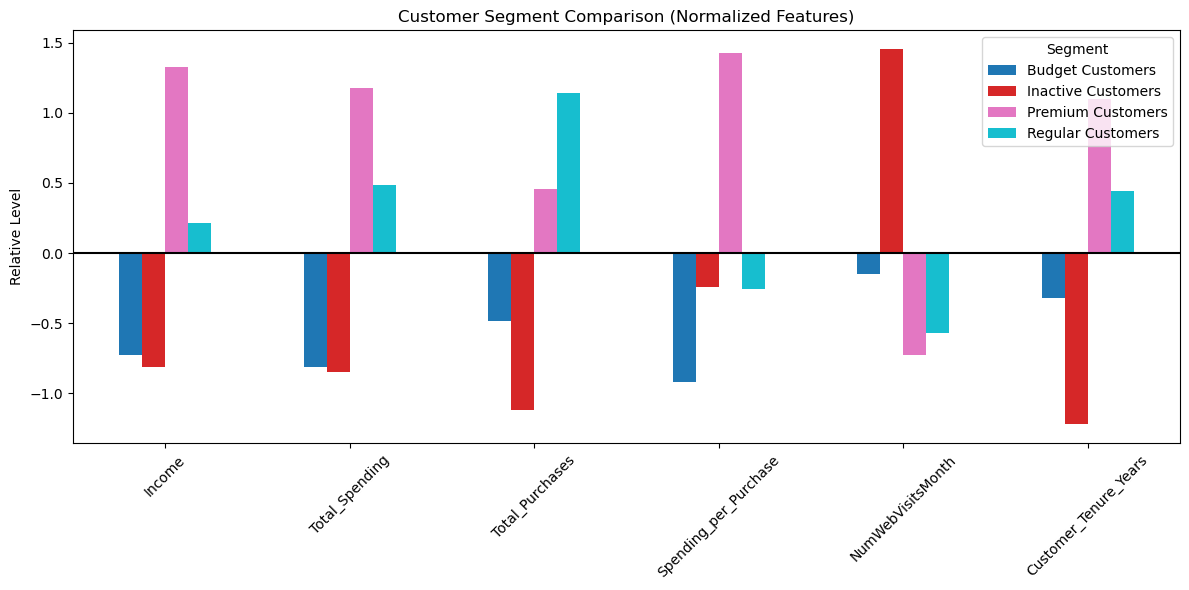

In [80]:
features_to_plot = [
    "Income",
    "Total_Spending",
    "Total_Purchases",
    "Spending_per_Purchase",
    "NumWebVisitsMonth",
    "Customer_Tenure_Years"
]

cluster_profile = df.groupby("Customer_Segment")[features_to_plot].mean()

cluster_profile_norm = cluster_profile.apply(
    lambda x: (x - x.mean()) / x.std(),
    axis=0
)

cluster_profile_norm.T.plot(
    kind='bar',
    figsize=(12,6),
    colormap="tab10"
)

plt.title("Customer Segment Comparison (Normalized Features)")
plt.axhline(0, color='black')
plt.ylabel("Relative Level")
plt.xticks(rotation=45)
plt.legend(title="Segment")
plt.tight_layout()
plt.show()

In [84]:
'''
The clustering analysis identified four distinct customer segments. Premium customers exhibit high income and spending behavior, 
indicating strong purchasing power and low price sensitivity. Regular customers are frequent buyers contributing steady revenue. 
Budget customers demonstrate low engagement and spending, suggesting price sensitivity. Inactive customers show high browsing 
activity but low conversion, representing a key opportunity for targeted marketing strategies.
'''

'\nThe clustering analysis identified four distinct customer segments. Premium customers exhibit high income and spending behavior, \nindicating strong purchasing power and low price sensitivity. Regular customers are frequent buyers contributing steady revenue. \nBudget customers demonstrate low engagement and spending, suggesting price sensitivity. Inactive customers show high browsing \nactivity but low conversion, representing a key opportunity for targeted marketing strategies.\n'

In [85]:
import joblib

# Save model + scaler + features
joblib.dump(gmm, "gmm_model.pkl")
joblib.dump(scaler, "scaler.pkl")

# Save feature order (important for prediction)
features = [
    "Age",
    "Income",
    "Recency",
    "Total_Spending",
    "Total_Purchases",
    "Spending_per_Purchase",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth",
    "Customer_Tenure_Years",
    "Total_Children"
]

joblib.dump(features, "features.pkl")

print("Model saved successfully!")

Model saved successfully!
